---
Phase 1-2: 邏輯回歸 (Logistic Regression)
---

從回歸到分類的關鍵一步。

線性回歸的問題：
  y = wx + b 輸出是任意實數 (-∞ ~ +∞)
  但分類問題需要的是「機率」(0 ~ 1)

解法：加一個 Sigmoid 函數！
  P(y=1|x) = σ(wx + b) = 1 / (1 + e^(-(wx+b)))
  把任意實數壓縮到 (0, 1) 之間

本檔涵蓋：
  Part A: Sigmoid 函數與概念
  Part B: NumPy 手刻（二元分類）
  Part C: Scikit-learn 版
  Part D: 多類別分類（Softmax）

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Part A: Sigmoid 函數
# ============================================================================

Part A: Sigmoid 函數 — 把數字變成機率
    z  →  σ(z)
--------------------
  -10  →  0.0000
   -5  →  0.0067
   -2  →  0.1192
   -1  →  0.2689
    0  →  0.5000
    1  →  0.7311
    2  →  0.8808
    5  →  0.9933
   10  →  1.0000

觀察：
  z 很大 (正) → σ(z) ≈ 1  （很有信心是正類）
  z = 0       → σ(z) = 0.5（完全不確定）
  z 很大 (負) → σ(z) ≈ 0  （很有信心是負類）

  z = wx + b 叫做 "logit"
  σ(z) 是模型預測「正類」的機率



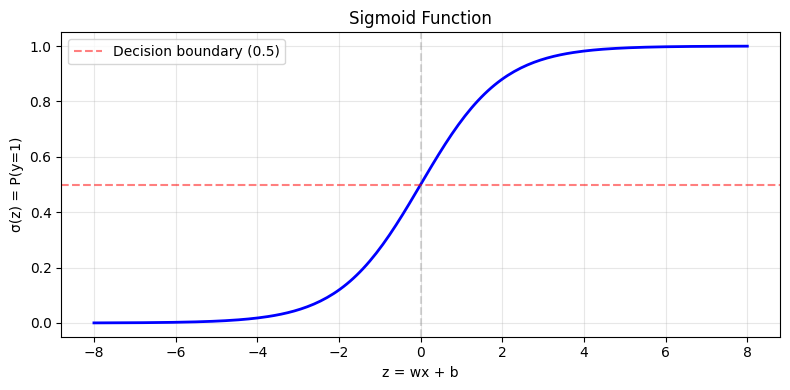

In [2]:
print("=" * 60)
print("Part A: Sigmoid 函數 — 把數字變成機率")
print("=" * 60)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 看 Sigmoid 的行為
z_values = np.array([-10, -5, -2, -1, 0, 1, 2, 5, 10])
print(f"{'z':>5s}  →  σ(z)")
print("-" * 20)
for z in z_values:
    print(f"{z:5.0f}  →  {sigmoid(z):.4f}")

print("""
觀察：
  z 很大 (正) → σ(z) ≈ 1  （很有信心是正類）
  z = 0       → σ(z) = 0.5（完全不確定）
  z 很大 (負) → σ(z) ≈ 0  （很有信心是負類）

  z = wx + b 叫做 "logit"
  σ(z) 是模型預測「正類」的機率
""")

# 畫 Sigmoid
plt.figure(figsize=(8, 4))
z = np.linspace(-8, 8, 200)
plt.plot(z, sigmoid(z), 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.xlabel('z = wx + b')
plt.ylabel('σ(z) = P(y=1)')
plt.title('Sigmoid Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/02_sigmoid.png', dpi=100)
plt.show()

## Part B: NumPy 手刻 — 二元分類

Part B: NumPy 手刻 — 二元邏輯回歸
資料: 200 樣本, 2 特徵, 2 類別
X shape: (200, 2), y shape: (200,)
類別分佈: 0=100, 1=100

訓練開始 (lr=0.1, epochs=200)
Epoch   BCE Loss   Accuracy
------------------------------
    0     0.6931     50.00%
   25     0.2759     92.50%
   50     0.2181     92.50%
   75     0.1955     92.50%
  100     0.1836     92.50%
  125     0.1763     92.50%
  150     0.1713     92.50%
  175     0.1679     92.50%
  199     0.1654     92.50%

學到的權重: w = [1.5962 1.462 ], b = -0.0923


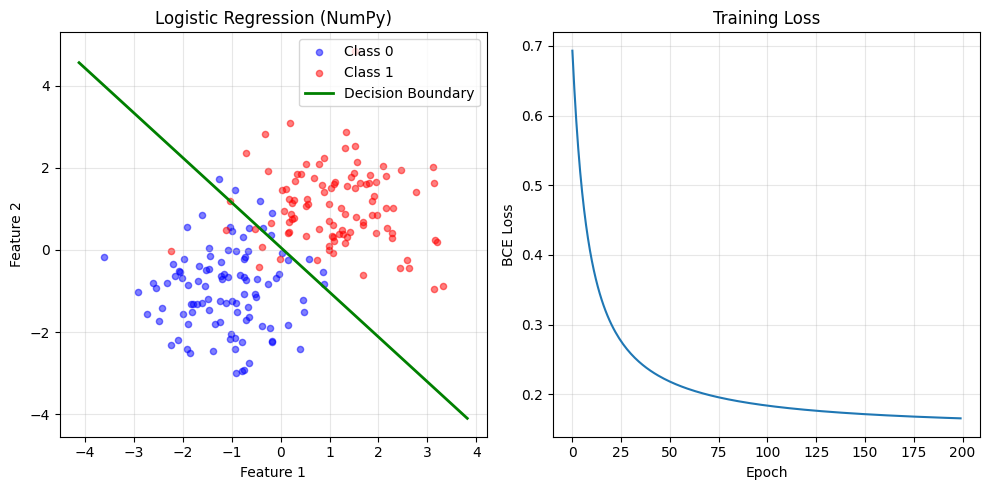

→ 圖表儲存至 plots/02_logistic_numpy.png


In [3]:
print("=" * 60)
print("Part B: NumPy 手刻 — 二元邏輯回歸")
print("=" * 60)

# --- 生成二元分類資料 ---
np.random.seed(42)
N = 200

# 類別 0：中心在 (-1, -1)
X0 = np.random.randn(N // 2, 2) + np.array([-1, -1])
# 類別 1：中心在 (1, 1)
X1 = np.random.randn(N // 2, 2) + np.array([1, 1])

X = np.vstack([X0, X1])                    # (200, 2)
y = np.array([0] * (N // 2) + [1] * (N // 2))   # (200,)

# 打亂順序
shuffle_idx = np.random.permutation(N)
X, y = X[shuffle_idx], y[shuffle_idx]

print(f"資料: {N} 樣本, 2 特徵, 2 類別")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"類別分佈: 0={np.sum(y==0)}, 1={np.sum(y==1)}")

# --- 訓練（梯度下降）---
# 模型：P(y=1|x) = σ(x @ w + b)
# 損失函數：Binary Cross-Entropy (BCE)
#   L = -(1/N) Σ [y·log(p) + (1-y)·log(1-p)]

w = np.zeros(2)     # 2 個特徵
b = 0.0
lr = 0.1
epochs = 200
loss_history = []

print(f"\n訓練開始 (lr={lr}, epochs={epochs})")
print(f"{'Epoch':>5} {'BCE Loss':>10} {'Accuracy':>10}")
print("-" * 30)

for epoch in range(epochs):
    # 前向傳播
    z = X @ w + b                        # (200,)
    p = sigmoid(z)                       # 預測機率 (200,)

    # Binary Cross-Entropy Loss
    eps = 1e-8   # 防止 log(0)
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    loss_history.append(loss)

    # 計算準確率
    predictions = (p >= 0.5).astype(int)
    accuracy = np.mean(predictions == y)

    # 梯度
    # ∂L/∂w = (1/N) Xᵀ(p - y)
    # ∂L/∂b = (1/N) Σ(p - y)
    error = p - y                        # (200,)
    dw = (1 / N) * (X.T @ error)        # (2,)
    db = (1 / N) * np.sum(error)

    # 更新
    w -= lr * dw
    b -= lr * db

    if epoch % 25 == 0 or epoch == epochs - 1:
        print(f"{epoch:5d} {loss:10.4f} {accuracy:10.2%}")

print(f"\n學到的權重: w = {w.round(4)}, b = {b:.4f}")

# 畫決策邊界
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', alpha=0.5, s=20, label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', alpha=0.5, s=20, label='Class 1')

# 決策邊界：w₁x₁ + w₂x₂ + b = 0 → x₂ = -(w₁x₁ + b) / w₂
x1_line = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
x2_line = -(w[0] * x1_line + b) / w[1]
plt.plot(x1_line, x2_line, 'g-', linewidth=2, label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression (NumPy)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/02_logistic_numpy.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/02_logistic_numpy.png")

## Part C: Scikit-learn 版

In [4]:
print("\n" + "=" * 60)
print("Part C: Scikit-learn 版")
print("=" * 60)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 切分訓練/測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"訓練集: {X_train.shape[0]} 樣本")
print(f"測試集: {X_test.shape[0]} 樣本")

# 訓練模型
clf = LogisticRegression()
clf.fit(X_train, y_train)

# 評估
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)    # 取得機率

print(f"\nsklearn 結果:")
print(f"  w (coef_):       {clf.coef_[0].round(4)}")
print(f"  b (intercept_):  {clf.intercept_[0]:.4f}")
print(f"  測試準確率:      {accuracy_score(y_test, y_pred):.2%}")

print(f"\n分類報告:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# predict vs predict_proba 的差異
print("predict_proba 示範（前 5 個樣本）:")
print(f"  {'真實':>4s}  {'P(0)':>6s}  {'P(1)':>6s}  {'預測':>4s}")
for i in range(5):
    print(f"  {y_test[i]:4d}  {y_prob[i, 0]:6.3f}  {y_prob[i, 1]:6.3f}  {y_pred[i]:4d}")


Part C: Scikit-learn 版


訓練集: 160 樣本
測試集: 40 樣本

sklearn 結果:
  w (coef_):       [1.7081 1.7323]
  b (intercept_):  -0.1807
  測試準確率:      95.00%

分類報告:
              precision    recall  f1-score   support

     Class 0       0.95      0.95      0.95        20
     Class 1       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40

predict_proba 示範（前 5 個樣本）:
    真實    P(0)    P(1)    預測
     1   0.159   0.841     1
     1   0.029   0.971     1
     1   0.005   0.995     1
     0   0.995   0.005     0
     1   0.063   0.937     1


## Part D: 多類別分類 — Softmax

In [5]:
print("\n" + "=" * 60)
print("Part D: 多類別分類 — Softmax Regression")
print("=" * 60)

print("""
二元分類用 Sigmoid：把 1 個數字變成機率
多類別分類用 Softmax：把 K 個數字變成 K 個機率（總和 = 1）

  Softmax(zᵢ) = exp(zᵢ) / Σⱼ exp(zⱼ)
""")

# 用 Iris 資料集（經典的 3 類分類問題）
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data       # (150, 4) — 4 個特徵
y_iris = iris.target     # (150,)   — 3 個類別 (0, 1, 2)

print(f"Iris 資料集: {X_iris.shape[0]} 樣本, {X_iris.shape[1]} 特徵, {len(set(y_iris))} 類別")
print(f"特徵: {iris.feature_names}")
print(f"類別: {iris.target_names}")

# --- NumPy 手刻 Softmax 回歸 ---
print("\n--- NumPy Softmax 回歸 ---")

def softmax(z):
    exp_z = np.exp(z - z.max(axis=1, keepdims=True))   # 減最大值防溢出
    return exp_z / exp_z.sum(axis=1, keepdims=True)

# 標準化特徵（很重要，梯度下降對特徵尺度敏感）
X_norm = (X_iris - X_iris.mean(axis=0)) / X_iris.std(axis=0)

# One-hot 編碼
n_classes = 3
Y_onehot = np.zeros((len(y_iris), n_classes))
Y_onehot[np.arange(len(y_iris)), y_iris] = 1

# 初始化
W = np.random.randn(4, 3) * 0.01    # (features, classes)
B = np.zeros((1, 3))
lr = 0.5

for epoch in range(300):
    # 前向傳播
    Z = X_norm @ W + B               # (150, 3)
    P = softmax(Z)                    # (150, 3) 每列是一個機率分佈

    # Cross-Entropy Loss
    loss = -np.mean(np.sum(Y_onehot * np.log(P + 1e-8), axis=1))

    # 梯度
    error = P - Y_onehot              # (150, 3)
    dW = (1 / len(y_iris)) * (X_norm.T @ error)   # (4, 3)
    dB = (1 / len(y_iris)) * error.sum(axis=0, keepdims=True)

    W -= lr * dW
    B -= lr * dB

    if epoch % 50 == 0:
        preds = P.argmax(axis=1)
        acc = np.mean(preds == y_iris)
        print(f"  Epoch {epoch:3d}: Loss={loss:.4f}, Accuracy={acc:.2%}")

preds = softmax(X_norm @ W + B).argmax(axis=1)
print(f"  最終準確率: {np.mean(preds == y_iris):.2%}")

# --- Scikit-learn 版 ---
print("\n--- Scikit-learn 版 ---")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y_iris, test_size=0.2, random_state=42)

clf_multi = LogisticRegression(max_iter=200)
clf_multi.fit(X_tr, y_tr)

print(f"  訓練準確率: {clf_multi.score(X_tr, y_tr):.2%}")
print(f"  測試準確率: {clf_multi.score(X_te, y_te):.2%}")
print(f"  權重矩陣 shape: {clf_multi.coef_.shape}")   # (3, 4) → 3 類 × 4 特徵

# 看預測機率
sample = X_te[:1]
probs = clf_multi.predict_proba(sample)
print(f"\n  一個樣本的預測機率:")
for i, name in enumerate(iris.target_names):
    print(f"    {name}: {probs[0, i]:.4f}")
print(f"  預測類別: {iris.target_names[clf_multi.predict(sample)[0]]}")


Part D: 多類別分類 — Softmax Regression

二元分類用 Sigmoid：把 1 個數字變成機率
多類別分類用 Softmax：把 K 個數字變成 K 個機率（總和 = 1）

  Softmax(zᵢ) = exp(zᵢ) / Σⱼ exp(zⱼ)

Iris 資料集: 150 樣本, 4 特徵, 3 類別
特徵: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
類別: ['setosa' 'versicolor' 'virginica']

--- NumPy Softmax 回歸 ---
  Epoch   0: Loss=1.0963, Accuracy=40.67%
  Epoch  50: Loss=0.2370, Accuracy=93.33%
  Epoch 100: Loss=0.1733, Accuracy=95.33%
  Epoch 150: Loss=0.1421, Accuracy=96.00%
  Epoch 200: Loss=0.1236, Accuracy=97.33%
  Epoch 250: Loss=0.1113, Accuracy=97.33%
  最終準確率: 97.33%

--- Scikit-learn 版 ---
  訓練準確率: 96.67%
  測試準確率: 100.00%
  權重矩陣 shape: (3, 4)

  一個樣本的預測機率:
    setosa: 0.0115
    versicolor: 0.8744
    virginica: 0.1141
  預測類別: versicolor


## 小結

In [6]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
邏輯回歸教會你的核心概念：

  概念                    對應到深度學習
  ──────────────────────────────────────────────────────
  Sigmoid                →  二元分類的輸出激活函數
  Softmax                →  多類別分類的輸出激活函數
  Binary Cross-Entropy   →  二元分類的損失函數
  Cross-Entropy          →  多類別分類的損失函數
  predict_proba          →  模型輸出機率，不只是類別

關鍵理解：
  線性回歸 + Sigmoid = 邏輯回歸（二元分類）
  線性回歸 + Softmax = Softmax 回歸（多類別分類）
  → 神經網路的最後一層就是這個！

sklearn 速查：
  from sklearn.linear_model import LogisticRegression
  clf = LogisticRegression()
  clf.fit(X_train, y_train)
  clf.predict(X_test)         # 預測類別
  clf.predict_proba(X_test)   # 預測機率
  clf.score(X_test, y_test)   # 準確率

下一步：03_knn.py — 最直覺的分類方式
""")


小結

邏輯回歸教會你的核心概念：

  概念                    對應到深度學習
  ──────────────────────────────────────────────────────
  Sigmoid                →  二元分類的輸出激活函數
  Softmax                →  多類別分類的輸出激活函數
  Binary Cross-Entropy   →  二元分類的損失函數
  Cross-Entropy          →  多類別分類的損失函數
  predict_proba          →  模型輸出機率，不只是類別

關鍵理解：
  線性回歸 + Sigmoid = 邏輯回歸（二元分類）
  線性回歸 + Softmax = Softmax 回歸（多類別分類）
  → 神經網路的最後一層就是這個！

sklearn 速查：
  from sklearn.linear_model import LogisticRegression
  clf = LogisticRegression()
  clf.fit(X_train, y_train)
  clf.predict(X_test)         # 預測類別
  clf.predict_proba(X_test)   # 預測機率
  clf.score(X_test, y_test)   # 準確率

下一步：03_knn.py — 最直覺的分類方式

